# Landslide Exposure Analysis

This notebook identifies which road segments are exposed to **landslide hazards** using two complementary datasets:

1. **Recorded landslide locations** (`Nestabilne_pojave.shp`) — point/polygon data of historical landslide events along roads
2. **Landslide susceptibility map** (`landslide_susceptibility.tif`) — a raster classifying terrain into five susceptibility levels

**Key steps:**
1. Load road network and landslide data
2. Filter to true landslides (excluding rockfalls, debris flows, etc.)
3. Visualise recorded landslides by year
4. Visualise the landslide susceptibility raster
5. Overlay landslides onto roads via spatial join
6. Save results as ArcGIS layers

## Step 1: Setup and Imports

In [16]:
import warnings
from pathlib import Path

import contextily as cx
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from rasterio.warp import transform_bounds

warnings.simplefilter(action="ignore", category=FutureWarning)

### Helper functions

In [17]:
# Helper functions

def save_lyrx_layer(gdf, gpkg_path, lyrx_path, layer_name, labels, colors, width_mapping, field, title=None):
    """Save GeoDataFrame to GeoPackage + ArcGIS Pro .lyrx with unique-value symbology."""
    import json as _json

    gdf.to_file(gpkg_path, driver="GPKG", layer=layer_name)
    print(f"Saved GeoPackage → {gpkg_path}")

    try:
        import arcpy
    except ImportError:
        print("arcpy not available — .lyrx skipped. GeoPackage was saved successfully.")
        return

    title = title or layer_name
    gpkg_layer_path = str(gpkg_path.absolute()) + f"/{layer_name}"
    tmp_layer_name = f"tmp_lyr_{layer_name}"
    arcpy.management.MakeFeatureLayer(gpkg_layer_path, tmp_layer_name)
    tmp_lyrx = lyrx_path.with_suffix(".tmp.lyrx")
    arcpy.management.SaveToLayerFile(tmp_layer_name, str(tmp_lyrx), "ABSOLUTE")
    arcpy.management.Delete(tmp_layer_name)

    with open(tmp_lyrx) as f:
        lyrx = _json.load(f)

    def _make_symbol(hex_color, width):
        h = hex_color.lstrip("#")
        r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
        return {
            "type": "CIMSymbolReference",
            "symbol": {
                "type": "CIMLineSymbol",
                "symbolLayers": [{
                    "type": "CIMSolidStroke", "enable": True,
                    "capStyle": "Round", "joinStyle": "Round",
                    "width": width,
                    "color": {"type": "CIMRGBColor", "values": [r, g, b, 100]},
                }],
            },
        }

    renderer = {
        "type": "CIMUniqueValueRenderer",
        "defaultLabel": "<all other values>",
        "defaultSymbolPatch": "Default",
        "defaultSymbol": _make_symbol("#cccccc", 0.5),
        "defaultSymbolVisible": False,
        "fields": [field],
        "groups": [{
            "type": "CIMUniqueValueGroup",
            "classes": [
                {
                    "type": "CIMUniqueValueClass",
                    "label": label, "patch": "Default",
                    "symbol": _make_symbol(color, width_mapping.get(label, 1.0)),
                    "values": [{"type": "CIMUniqueValue", "fieldValues": [label]}],
                    "visible": True,
                }
                for label, color in zip(labels, colors)
            ],
            "heading": field,
        }],
        "useDefaultSymbol": False,
    }

    lyrx["layerDefinitions"][0]["renderer"] = renderer
    lyrx["layerDefinitions"][0]["name"] = title

    with open(lyrx_path, "w") as f:
        _json.dump(lyrx, f, indent=2)

    tmp_lyrx.unlink()
    print(f"Saved layer file → {lyrx_path}")

### Define file paths

In [18]:
BASE_DIR = Path(r"C:\Users\eks510\OneDrive - Vrije Universiteit Amsterdam\2_Projects\AFD_Serbia\Analysis\criticality_serbia_workshop_day2")

data_path = BASE_DIR / "input_files"
figure_path = BASE_DIR / "figures"
arcgis_results = BASE_DIR / "results" / "ArcGIS layers"
arcgis_gpkg = arcgis_results / "Geopackages"

# Create output directories if they don't exist
figure_path.mkdir(parents=True, exist_ok=True)
arcgis_results.mkdir(parents=True, exist_ok=True)
arcgis_gpkg.mkdir(parents=True, exist_ok=True)

## Step 2: Load Data

### Road network and country boundary

In [19]:
# Load road network
roads = gpd.read_file(data_path / "DeoniceRSDP-Jul2025..shp")
print(f"Road segments loaded: {len(roads):,}")
print(f"CRS: {roads.crs}")

# Load country outline (for plotting)
world_path = data_path / "ne_10m_admin_0_countries.shp"
world = gpd.read_file(world_path)
country_plot = world.loc[world.SOV_A3 == 'SRB']
# Clip to Serbia only (remove Kosovo roads)
roads = gpd.clip(roads, country_plot.to_crs(roads.crs))


Road segments loaded: 2,023
CRS: EPSG:4326


### Recorded landslide events

The dataset contains various types of slope instability. We filter to keep only true landslides (`tip == 'Klizište'`), excluding rockfalls, slope detachments, debris flows, and degraded road surfaces.

In [21]:
landslides = gpd.read_file(data_path / "Nestabilne_pojave.shp")
print(f"Total unstable occurrences: {len(landslides):,}")
print(f"\nTypes of instability:")
print(landslides['tip'].value_counts())

# Filter to true landslides only
landslides = landslides[landslides['tip'] == 'Klizište']
print(f"\nLandslide occurrences after filtering: {len(landslides):,}")

Total unstable occurrences: 460

Types of instability:
tip
Klizište                       289
Otcepljenje kosine nasipa      121
Otcepljenje kosine zaseka       14
Odron                           12
Degradiran kolovozni zastor      9
Osuline - odroni                 8
Osuline                          5
Tecište                          2
Name: count, dtype: int64

Landslide occurrences after filtering: 289


## Step 3: Visualise Recorded Landslides

We classify landslide events by the year they were recorded — this gives an indication of both when events occurred and the evolution of monitoring coverage.

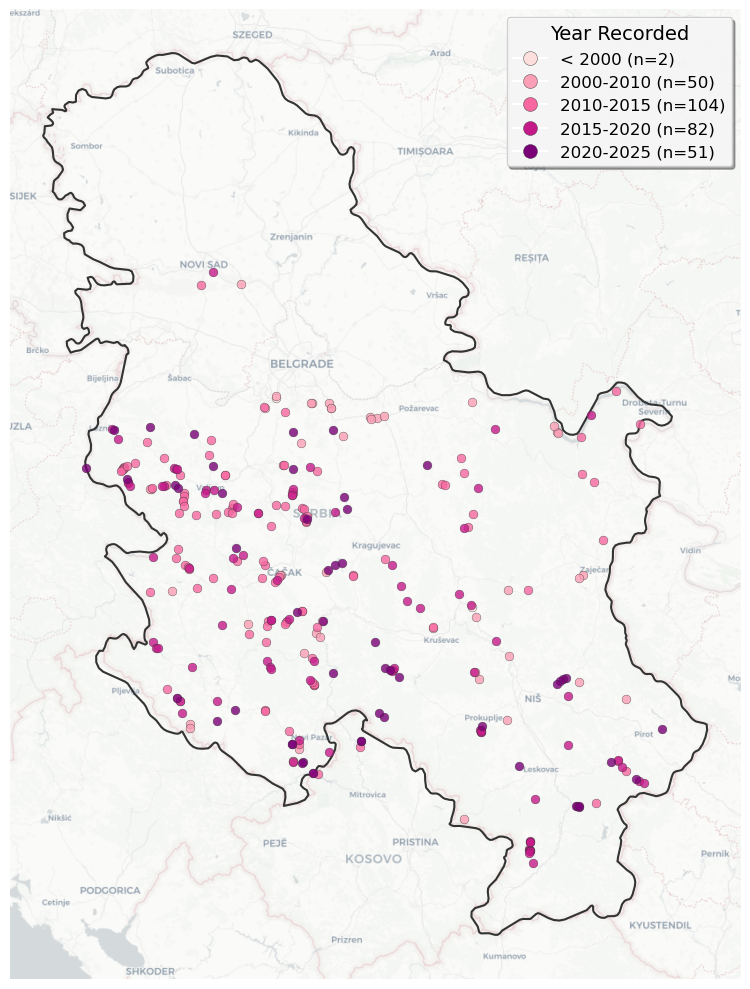

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10), facecolor='white')

serbia_mercator = country_plot.to_crs(3857)
landslides_mercator = landslides.to_crs(3857)

# Extract year from datum_evid
landslides_mercator['year'] = pd.to_datetime(landslides_mercator['datum_evid']).dt.year

# Year bins
bins = [0, 2000, 2010, 2015, 2020, 2030]
labels = ['< 2000', '2000-2010', '2010-2015', '2015-2020', '2020-2025']
landslides_mercator['year_class'] = pd.cut(
    landslides_mercator['year'],
    bins=bins, labels=labels, include_lowest=True
)

# Sequential colours — older to newer
colors = {
    '< 2000': '#fde0dd',
    '2000-2010': '#fa9fb5',
    '2010-2015': '#f768a1',
    '2015-2020': '#c51b8a',
    '2020-2025': '#7a0177'
}

# Country outline
serbia_mercator.plot(ax=ax, facecolor='none', edgecolor='#333333',
                     linewidth=1.5, zorder=2)

# Plot landslides by year class
for year_class in labels:
    subset = landslides_mercator[landslides_mercator['year_class'] == year_class]
    if len(subset) > 0:
        subset.plot(ax=ax, color=colors[year_class], markersize=40,
                    alpha=0.8, edgecolor='#333333',
                    linewidth=0.3, zorder=3)

cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron, attribution=False)
ax.set_aspect('equal')
ax.axis('off')

# Legend with counts
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=colors[label], markersize=10,
           markeredgecolor='#333333', markeredgewidth=0.3,
           label=f'{label} (n={len(landslides_mercator[landslides_mercator["year_class"] == label])})')
    for label in labels
]
ax.legend(handles=legend_elements, title='Year Recorded', loc='upper right',
          fontsize=12, title_fontsize=14,
          frameon=True, fancybox=True, shadow=True,
          framealpha=0.9, facecolor='white', edgecolor='#cccccc')

plt.tight_layout()
plt.savefig(figure_path / 'landslides_map_by_year.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 4: Visualise Landslide Susceptibility Map

The susceptibility raster classifies terrain into five discrete levels (values 2, 4, 6, 8, 10) from Very Low to Very High. This provides a broader picture of where landslides are likely, beyond just the recorded events.

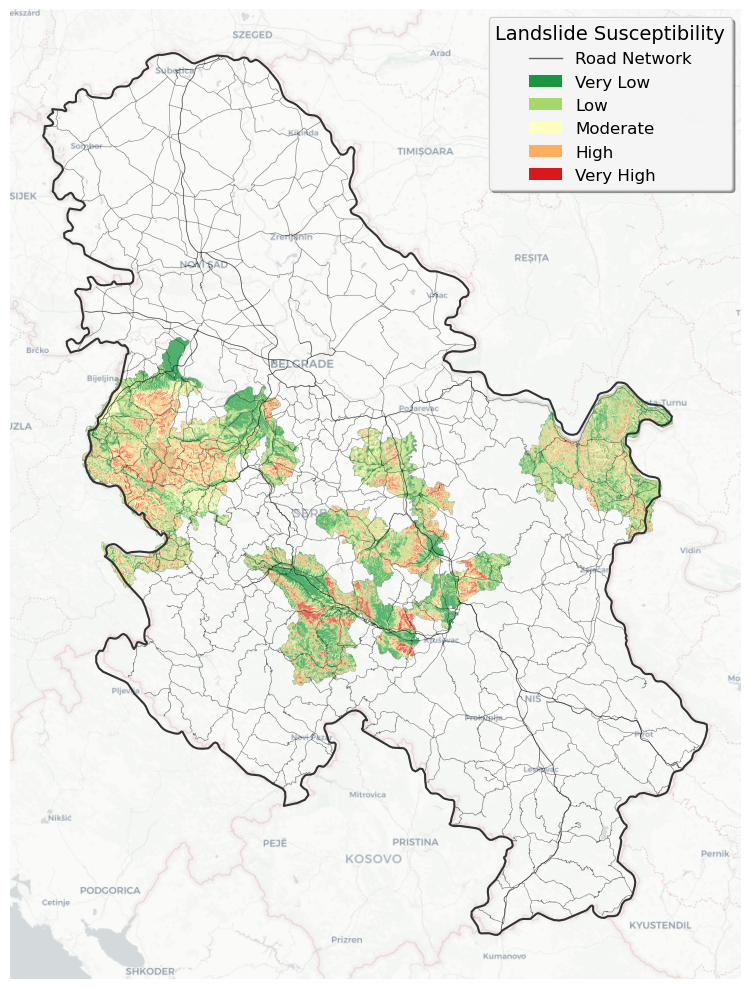

In [24]:
landslide_path = data_path / "landslide_susceptibility.tif"

with rasterio.open(landslide_path) as src:
    landslide_data = src.read(1).astype(float)
    landslide_data[landslide_data == src.nodata] = np.nan
    landslide_bounds = src.bounds
    landslide_crs = src.crs

    bounds_mercator = transform_bounds(
        landslide_crs, "EPSG:3857",
        landslide_bounds.left, landslide_bounds.bottom,
        landslide_bounds.right, landslide_bounds.top
    )

# Map discrete values to colours
susc_labels = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']
susc_colors = ['#1a9641', '#a6d96a', '#ffffbf', '#fdae61', '#d7191c']

value_to_color = {
    2:  mcolors.to_rgba('#1a9641', alpha=0.75),
    4:  mcolors.to_rgba('#a6d96a', alpha=0.75),
    6:  mcolors.to_rgba('#ffffbf', alpha=0.75),
    8:  mcolors.to_rgba('#fdae61', alpha=0.75),
    10: mcolors.to_rgba('#d7191c', alpha=0.75),
}

color_array = np.full((*landslide_data.shape, 4), 0.0)
for val, rgba in value_to_color.items():
    color_array[landslide_data == val] = rgba

# Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 10), facecolor='white')

serbia_mercator = country_plot.to_crs(3857)
roads_mercator = roads.to_crs(3857)

ax.imshow(
    color_array,
    extent=[bounds_mercator[0], bounds_mercator[2],
            bounds_mercator[1], bounds_mercator[3]],
    zorder=2, origin='upper'
)

serbia_mercator.plot(ax=ax, facecolor='none', edgecolor='#333333',
                     linewidth=1.5, zorder=4)
roads_mercator.plot(ax=ax, color='black', linewidth=0.4,
                    alpha=0.5, zorder=3)

cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron, attribution=False)
ax.set_aspect('equal')
ax.axis('off')

legend_elements = [
    Line2D([0], [0], color='black', linewidth=1, label='Road Network', alpha=0.6)
] + [
    Patch(facecolor=susc_colors[i], edgecolor='none', label=susc_labels[i])
    for i in range(len(susc_labels))
]
ax.legend(handles=legend_elements, title='Landslide Susceptibility', loc='upper right',
          fontsize=12, title_fontsize=14,
          frameon=True, fancybox=True, shadow=True,
          framealpha=0.9, facecolor='white', edgecolor='#cccccc')

plt.tight_layout()
plt.savefig(figure_path / 'landslide_susceptibility_map.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 5: Identify Exposed Roads

We buffer the landslide point locations by 10 meters and then perform a spatial join to find which road segments are affected. The buffer accounts for positional uncertainty in the landslide records.

In [61]:
# Buffer landslide geometries by 10m to account for positional uncertainty
landslides_buffered = landslides.copy()
landslides_buffered = landslides_buffered.to_crs(roads.crs)

#set to meters to ensure the right buffer
landslides_buffered = landslides_buffered.to_crs(8682)
landslides_buffered.geometry = landslides_buffered.geometry.buffer(10)


# Spatial join
roads_landslides = roads.to_crs(8682).sjoin(landslides_buffered, how="inner", predicate="intersects")

print(f"Road-landslide matches (before dedup): {len(roads_landslides):,}")

# A road can intersect multiple landslides — deduplicate
landslide_per_road = roads_landslides.groupby(roads_landslides.index).size().rename('landslide_count')

# Tag all roads
roads['landslide_exposed'] = roads.index.isin(landslide_per_road.index)
roads['landslide_count'] = landslide_per_road
roads['landslide_count'] = roads['landslide_count'].fillna(0).astype(int)

n_exposed = roads['landslide_exposed'].sum()
n_total = len(roads)
print(f"\nExposed road segments: {n_exposed:,} ({n_exposed / n_total * 100:.1f}%)")
print(f"Not exposed:           {n_total - n_exposed:,}")

Road-landslide matches (before dedup): 258

Exposed road segments: 133 (7.3%)
Not exposed:           1,695


### Visualise exposed road segments

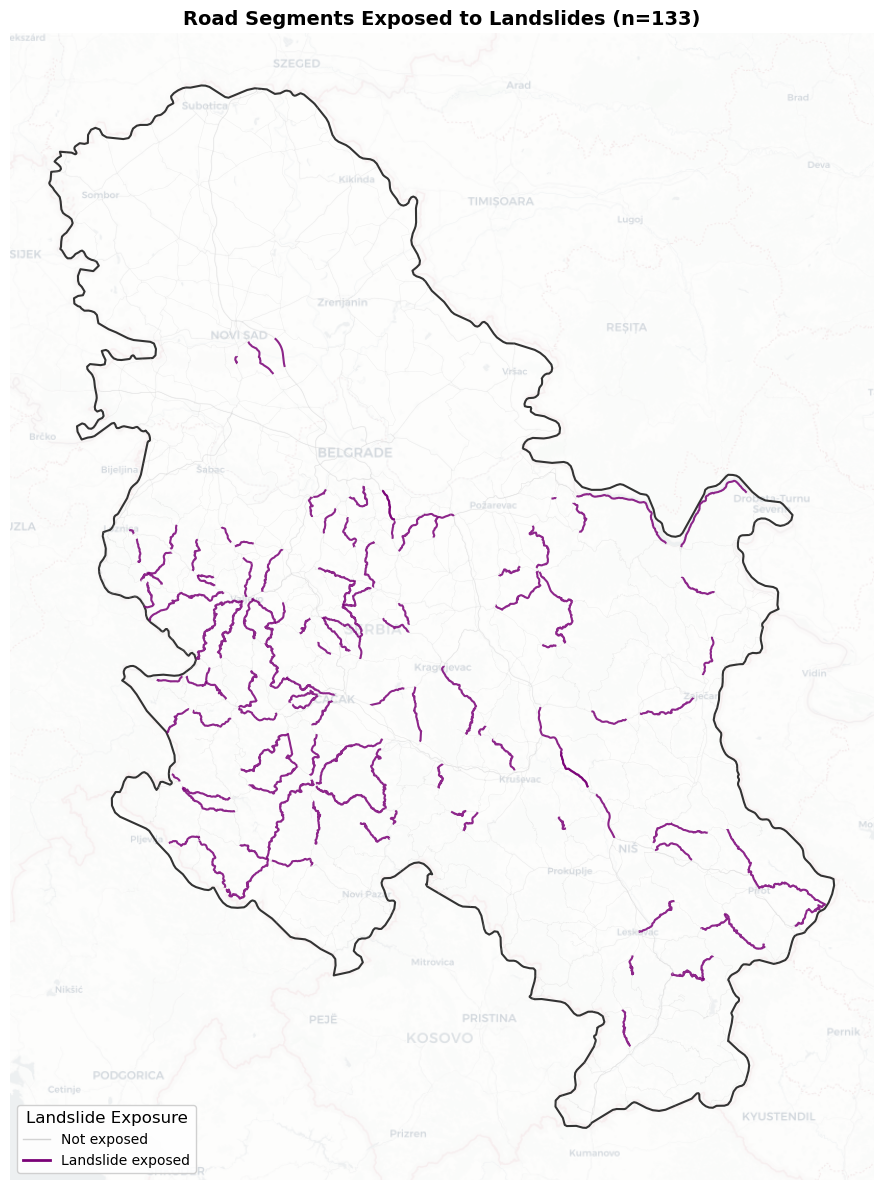

In [62]:
fig, ax = plt.subplots(1, 1, figsize=(9, 12), facecolor='white')

serbia_mercator = country_plot.to_crs(3857)
roads_mercator = roads.to_crs(3857)

# Country outline
serbia_mercator.plot(ax=ax, facecolor='none', edgecolor='#333333',
                     linewidth=1.5, zorder=1)

# Not exposed (grey)
roads_mercator[~roads_mercator['landslide_exposed']].plot(
    ax=ax, color='#d3d3d3', linewidth=0.3, alpha=0.4, zorder=1
)

# Exposed (dark pink/magenta — matching the landslide year colour scheme)
roads_mercator[roads_mercator['landslide_exposed']].plot(
    ax=ax, color='#7a0177', linewidth=1.5, alpha=0.85, zorder=2
)

cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron,
               alpha=0.4, attribution=False)
ax.axis('off')

legend_handles = [
    Line2D([0], [0], color='#d3d3d3', lw=1, label='Not exposed'),
    Line2D([0], [0], color='#7a0177', lw=2, label='Landslide exposed'),
]
ax.legend(handles=legend_handles, title="Landslide Exposure",
          loc="lower left", fontsize=10, title_fontsize=12,
          frameon=True, fancybox=True, framealpha=0.9,
          facecolor='white', edgecolor='#cccccc')

ax.set_title(f"Road Segments Exposed to Landslides (n={n_exposed:,})",
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(figure_path / 'landslide_exposure_roads.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 6: Save Results as ArcGIS Layers

The results are saved as a GeoPackage and ArcGIS Pro layer file. Open the `.lyrx` file in ArcGIS Pro to see the results on your map.

In [63]:
roads['landslide_class'] = np.where(roads['landslide_exposed'], "Landslide zone", "Not exposed")

save_lyrx_layer(
    gdf=roads,
    gpkg_path=arcgis_gpkg / "landslide_exposure_roads.gpkg",
    lyrx_path=arcgis_results / "landslide_exposure_roads.lyrx",
    layer_name="landslide_exposure_roads",
    labels=["Not exposed", "Landslide zone"],
    colors=["#d3d3d3", "#7a0177"],
    width_mapping={"Not exposed": 0.3, "Landslide zone": 1.5},
    field="landslide_class",
    title="Landslide Exposure on Roads",
)

print("\n✅ Done! Open 'landslide_exposure_roads.lyrx' in ArcGIS Pro to view the results.")

Saved GeoPackage → C:\Users\eks510\OneDrive - Vrije Universiteit Amsterdam\2_Projects\AFD_Serbia\Analysis\criticality_serbia_workshop_day2\results\ArcGIS layers\Geopackages\landslide_exposure_roads.gpkg
Saved layer file → C:\Users\eks510\OneDrive - Vrije Universiteit Amsterdam\2_Projects\AFD_Serbia\Analysis\criticality_serbia_workshop_day2\results\ArcGIS layers\landslide_exposure_roads.lyrx

✅ Done! Open 'landslide_exposure_roads.lyrx' in ArcGIS Pro to view the results.
